In [1]:
import jax.numpy as jnp
import numpy as onp
import matplotlib.pyplot as plt
import matplotlib
from sklearn.linear_model import LinearRegression
from scipy.stats import linregress
import pandas as pd
import seaborn as sns
import time

font = {"size": 20}
matplotlib.rc("font", **font)
matplotlib.rcParams["text.usetex"] = True

import sys
sys.path.append("../../models")
from linear_sscr import LinearSSCR

<frozen importlib._bootstrap>:219: RuntimeWarning: scipy._lib.messagestream.MessageStream size changed, may indicate binary incompatibility. Expected 56 from C header, got 64 from PyObject


In [3]:

sample_size_list = [20, 100] #, 200, 500, 1_000]
p = 2
d = 1
n_repititions = 2
results = onp.zeros((n_repititions, len(sample_size_list)))

for ii in range(n_repititions):
    for jj, sample_size in enumerate(sample_size_list):

        n, m = sample_size, sample_size

        zx = onp.random.normal(size=(n, d))
        zy = onp.random.normal(size=(m, d))
        t = onp.random.normal(size=(n, d))
        W = onp.random.normal(size=(d, p))
        S = onp.random.normal(size=(d, p))
        beta = onp.random.normal(size=(d, 1))
        sigma2 = 1e-2
        tau2 = 1e-2

        X = zx @ S + t @ W + onp.random.normal(scale=sigma2, size=(n, p))
        Y = zy @ S + onp.random.normal(scale=sigma2, size=(m, p))
        R = t @ beta + onp.random.normal(scale=tau2, size=(n, 1))

        model = LinearSSCR()
        start = time.time()
        model.fit(X, Y, R, d, verbose=False)
        end = time.time()

        results[ii, jj] = end - start

results_df_sample_size = pd.melt(pd.DataFrame(results, columns=sample_size_list))

In [4]:

p_list = [20, 100] #, 200, 500, 1_000]
n = 200
m = 200
d = 1
n_repititions = 2
results = onp.zeros((n_repititions, len(p_list)))

for ii in range(n_repititions):
    for jj, p in enumerate(p_list):

        zx = onp.random.normal(size=(n, d))
        zy = onp.random.normal(size=(m, d))
        t = onp.random.normal(size=(n, d))
        W = onp.random.normal(size=(d, p))
        S = onp.random.normal(size=(d, p))
        beta = onp.random.normal(size=(d, 1))
        sigma2 = 1e-2
        tau2 = 1e-2

        X = zx @ S + t @ W + onp.random.normal(scale=sigma2, size=(n, p))
        Y = zy @ S + onp.random.normal(scale=sigma2, size=(m, p))
        R = t @ beta + onp.random.normal(scale=tau2, size=(n, 1))

        model = LinearSSCR()
        start = time.time()
        model.fit(X, Y, R, d, verbose=False)
        end = time.time()

        results[ii, jj] = end - start

results_df_p = pd.melt(pd.DataFrame(results, columns=p_list))

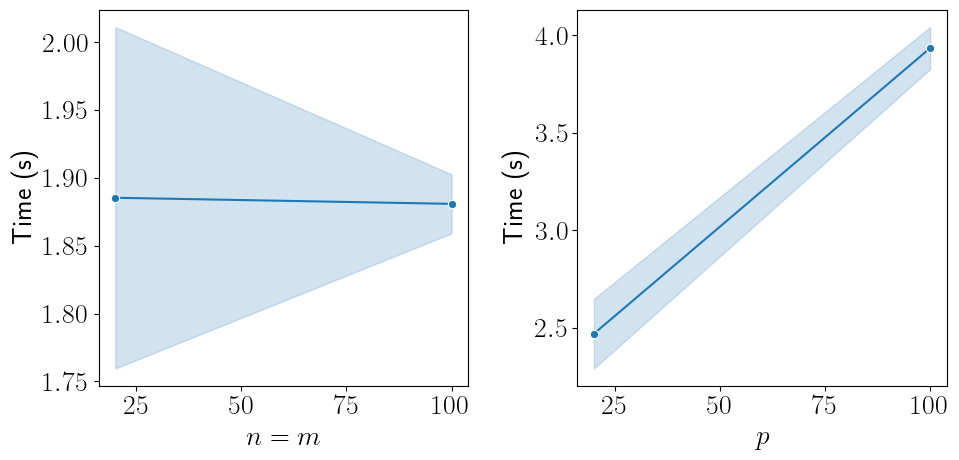

In [6]:
plt.figure(figsize=(10, 5))

plt.subplot(121)
sns.lineplot(data=results_df_sample_size, x="variable", y="value", marker="o")
plt.xlabel(r"$n = m$")
plt.ylabel(r"Time (s)")
# plt.ylim(0.6, 1.1)

plt.subplot(122)
sns.lineplot(data=results_df_p, x="variable", y="value", marker="o")
plt.xlabel(r"$p$")
plt.ylabel(r"Time (s)")
# plt.ylim(0.6, 1.1)

plt.tight_layout()
plt.show()